In [1]:
import pandas as pd

In [48]:
data = pd.read_excel(r'C:\Users\ADMIN\OneDrive\Desktop\ML\ML Live Flight Fare Resourses16963295320.xlsx')

In [49]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [56]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [57]:
data.isnull().any()

Airline            False
Date_of_Journey    False
Source             False
Destination        False
Route               True
Dep_Time           False
Arrival_Time       False
Duration           False
Total_Stops         True
Additional_Info    False
Price              False
dtype: bool

In [58]:
data["Additional_Info"].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [59]:
data.drop("Route", axis = 1, inplace = True)

In [60]:
data.drop("Additional_Info", axis = 1, inplace = True)

In [61]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,7662


In [62]:
import warnings
warnings.filterwarnings("ignore")

In [63]:
data["Journey_year"] = pd.to_datetime(data["Date_of_Journey"]).dt.year
data["Journey_month"] = pd.to_datetime(data["Date_of_Journey"]).dt.month
data["Journey_day"] = pd.to_datetime(data["Date_of_Journey"]).dt.day

In [64]:
data.drop(["Date_of_Journey","Journey_year"], axis = 1, inplace=True)

In [65]:
data.head(2)

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_month,Journey_day
0,IndiGo,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,3897,3,24
1,Air India,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,7662,5,1


In [66]:
data["Dep_hour"] = pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_minute"] = pd.to_datetime(data["Dep_Time"]).dt.minute

In [67]:
data["Arrival_hour"] = pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_minute"] = pd.to_datetime(data["Arrival_Time"]).dt.minute

In [68]:
data.drop(["Dep_Time","Arrival_Time"], axis = 1, inplace = True)

In [69]:
data.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,3897,3,24,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,7662,5,1,5,50,13,15


<Axes: xlabel='Airline'>

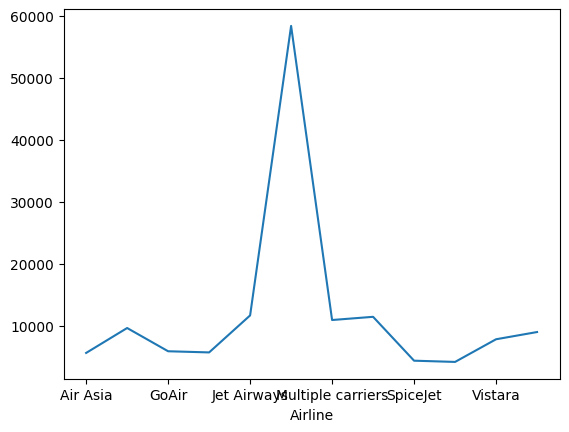

In [70]:
data.groupby("Airline")["Price"].mean().plot()

In [71]:
Airline = pd.get_dummies(data["Airline"], dtype=int)
Source = pd.get_dummies(data["Source"], dtype=int)
Destination = pd.get_dummies(data["Destination"], dtype=int)

In [72]:
Source.head(20)

,Banglore,Chennai,Delhi,Kolkata,Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,1,0
4,1,0,0,0,0
5,0,0,0,1,0
6,1,0,0,0,0
7,1,0,0,0,0
8,1,0,0,0,0
9,0,0,1,0,0


In [73]:
data = pd.concat([data, Airline, Source, Destination], axis=1)
pd.set_option("display.max_columns", None)

In [74]:
data.drop(["Airline","Source","Destination"], axis = 1, inplace = True)

In [75]:
data.head(2)

,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,2h 50m,non-stop,3897,3,24,22,20,1,10,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1,7h 25m,2 stops,7662,5,1,5,50,13,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [76]:
data["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [77]:
data["Total_Stops"].isnull().any()

np.True_

In [78]:
data[data["Total_Stops"].isnull() == True]

,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
9039,23h 40m,NaN,7480,5,6,9,45,9,25,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0


In [79]:
data["Total_Stops"] = data["Total_Stops"].ffill()

In [80]:
data.loc[[9039]]

,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
9039,23h 40m,non-stop,7480,5,6,9,45,9,25,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0


In [81]:
data["Total_Stops"] = data["Total_Stops"].replace(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'], [0,2,1,3,4])

In [82]:
data.head(2)

,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,2h 50m,0,3897,3,24,22,20,1,10,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1,7h 25m,2,7662,5,1,5,50,13,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [83]:
data["Duration_hour"] = data["Duration"].str.split().str[0]
data["Duration_minute"] = data["Duration"].str.split().str[1]

In [84]:
data["Duration_hour"] = data["Duration_hour"].replace("[h]","", regex = True)
data["Duration_minute"] = data["Duration_minute"].replace("[m]","", regex = True)

In [85]:
data.head(2)

,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Duration_hour,Duration_minute
0,2h 50m,0,3897,3,24,22,20,1,10,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,50
1,7h 25m,2,7662,5,1,5,50,13,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,7,25


In [86]:
data.fillna(0).head()

,Duration,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Duration_hour,Duration_minute
0,2h 50m,0,3897,3,24,22,20,1,10,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,50
1,7h 25m,2,7662,5,1,5,50,13,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,7,25
2,19h,2,13882,6,9,9,25,4,25,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,19,0
3,5h 25m,1,6218,5,12,18,5,23,30,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,5,25
4,4h 45m,1,13302,3,1,16,50,21,35,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,4,45


In [87]:
data.drop("Duration", axis = 1, inplace = True)

In [88]:
data.head(2)

,Total_Stops,Price,Journey_month,Journey_day,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Duration_hour,Duration_minute
0,0,3897,3,24,22,20,1,10,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,50
1,2,7662,5,1,5,50,13,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,7,25


In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Total_Stops                        10683 non-null  int64 
 1   Price                              10683 non-null  int64 
 2   Journey_month                      10683 non-null  int32 
 3   Journey_day                        10683 non-null  int32 
 4   Dep_hour                           10683 non-null  int32 
 5   Dep_minute                         10683 non-null  int32 
 6   Arrival_hour                       10683 non-null  int32 
 7   Arrival_minute                     10683 non-null  int32 
 8   Air Asia                           10683 non-null  int64 
 9   Air India                          10683 non-null  int64 
 10  GoAir                              10683 non-null  int64 
 11  IndiGo                             10683 non-null  int64 
 12  Jet 

In [94]:
data["Duration_hour"] = data["Duration_hour"].astype("int")
data["Duration_minute"] = data["Dep_minute"].astype("int")

In [95]:
data["Duration_hour"] = data["Duration_hour"].replace("[m]","", regex = True)

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Total_Stops                        10683 non-null  int64
 1   Price                              10683 non-null  int64
 2   Journey_month                      10683 non-null  int32
 3   Journey_day                        10683 non-null  int32
 4   Dep_hour                           10683 non-null  int32
 5   Dep_minute                         10683 non-null  int32
 6   Arrival_hour                       10683 non-null  int32
 7   Arrival_minute                     10683 non-null  int32
 8   Air Asia                           10683 non-null  int64
 9   Air India                          10683 non-null  int64
 10  GoAir                              10683 non-null  int64
 11  IndiGo                             10683 non-null  int64
 12  Jet Airways       

In [97]:
x = data.drop("Price", axis = 1)
y = data["Price"]

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42)

In [100]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [101]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
model.score(x_train, y_train)

0.6251096584552361

In [103]:
model.score(x_test, y_test)

0.6150373747203497

In [104]:
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor()

In [105]:
model.fit(x,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


### Feature Selection

<Axes: >

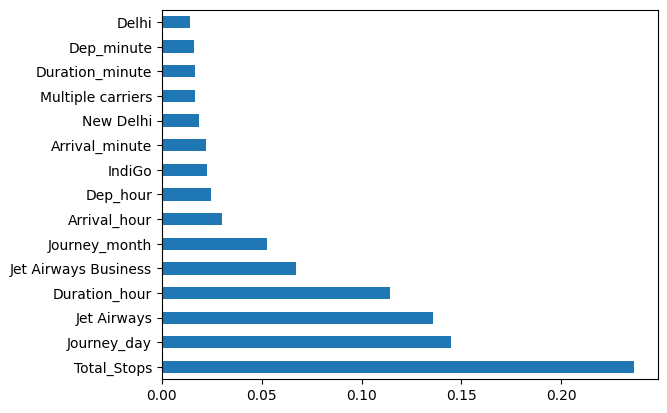

In [115]:
a = pd.Series(model.feature_importances_, index = x.columns)
a.nlargest(15).plot(kind = "barh")

### Applying all models 

In [116]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [117]:
all_model = [DecisionTreeRegressor, KNeighborsRegressor, RandomForestRegressor, SVR]

for i in all_model:
    model = i()
    model = model.fit(x_train, y_train)
    print(i, 'accuracy', model.score(x_test,y_test))

<class 'sklearn.tree._classes.DecisionTreeRegressor'> accuracy 0.6743012129818786
<class 'sklearn.neighbors._regression.KNeighborsRegressor'> accuracy 0.5401609549650255
<class 'sklearn.ensemble._forest.RandomForestRegressor'> accuracy 0.7875098848195803
<class 'sklearn.svm._classes.SVR'> accuracy -0.004013065772166868


In [132]:
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor(550, random_state=50)

In [133]:
model2.fit(x_train, y_train)

,n_estimators,550
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [134]:
yp = model2.predict(x_test)
yp

array([13649.11669697,  5634.96181818, 12303.43587879, ...,
        6619.08909091,  4826.37272727, 11363.25911688], shape=(2137,))

In [135]:
model2.score(x_train, y_train)

0.9546640993975489

In [136]:
model2.score(x_test, y_test)

0.7879860949489164